In [87]:
import itertools
import spot


def extract_atomic_propositions(*formulas: str) -> list[str]:
    """Extract all unique atomic propositions (APs) across given LTL formulas."""
    aps = set()
    for f in formulas:
        parsed = spot.formula(f)
        for ap in spot.atomic_prop_collect(parsed):
            aps.add(ap.ap_name())
    return sorted(list(aps))


def generate_all_traces(aps: list[str], k: int) -> list[tuple[str, ...]]:
    """Generate all 2^(|AP| * k) possible execution traces of length k."""
    if not aps or k <= 0:
        return [()]

    step_valuations = []
    for truth_values in itertools.product([True, False], repeat=len(aps)):
        literals = [ap if is_true else f"!{ap}" for ap, is_true in zip(aps, truth_values)]
        step_valuations.append(" & ".join(literals))

    return list(itertools.product(step_valuations, repeat=k))


def get_satisfying_traces(formula_str: str, aps: list[str], k: int) -> set[tuple[str, ...]]:
    """Finds all length-k traces that satisfy the formula under LTLf semantics."""
    # Convert LTLf formula string -> LTL formula -> Automaton graph (twa_graph)
    aut = spot.translate(spot.from_ltlf(formula_str))
    dict_ptr = aut.get_dict()
    
    all_traces = generate_all_traces(aps, k)
    satisfying_traces = set()

    for trace in all_traces:
        if trace:
            prefix = " ; ".join(f"({step}) & alive" for step in trace)
            word_str = f"{prefix} ; cycle{{!alive}}"
        else:
            word_str = "cycle{!alive}"

        word = spot.parse_word(word_str, dict_ptr)
        word_aut = word.as_automaton()

        if not spot.product(aut, word_aut).is_empty():
            satisfying_traces.add(trace)

    return satisfying_traces


def ltl_jaccard_metrics(f1: str, f2: str, k: int, aps: list[str] = None) -> tuple[float, float]:
    """Computes (Jaccard Similarity, Jaccard Distance) between two LTL formulas over horizon k."""
    if aps is None:
        aps = extract_atomic_propositions(f1, f2)

    t1 = get_satisfying_traces(f1, aps, k)
    t2 = get_satisfying_traces(f2, aps, k)

    intersection_size = len(t1.intersection(t2))
    union_size = len(t1.union(t2))

    if union_size == 0:
        similarity = 1.0
    else:
        similarity = intersection_size / union_size

    distance = 1.0 - similarity
    return similarity, distance


def compute_pairwise_similarity_matrix(formulas: list[str], k: int) -> tuple[list[list[float]], list[str]]:
    """Generates an NxN pairwise similarity matrix for candidate responses."""
    aps = extract_atomic_propositions(*formulas)
    n = len(formulas)
    matrix = [[1.0] * n for _ in range(n)]

    trace_sets = [get_satisfying_traces(f, aps, k) for f in formulas]

    for i in range(n):
        for j in range(i + 1, n):
            t1, t2 = trace_sets[i], trace_sets[j]
            union_len = len(t1.union(t2))
            sim = 1.0 if union_len == 0 else len(t1.intersection(t2)) / union_len
            matrix[i][j] = sim
            matrix[j][i] = sim

    return matrix, aps


# Example Usage
if __name__ == "__main__":
    f1 = "G(a -> F b)"
    f2 = "!(F(a & G(!b)))"  # Semantically equivalent to f1
    f3 = "F a"              # Semantically distinct

    horizon = 5

    sim_12, dist_12 = ltl_jaccard_metrics(f1, f2, k=horizon)
    print(f"Jaccard Similarity (f1 vs f2): {sim_12:.4f}")
    print(f"Jaccard Distance   (f1 vs f2): {dist_12:.4f}\n")

    sim_13, dist_13 = ltl_jaccard_metrics(f1, f3, k=horizon)
    print(f"Jaccard Similarity (f1 vs f3): {sim_13:.4f}")
    print(f"Jaccard Distance   (f1 vs f3): {dist_13:.4f}\n")

    responses = [f1, f2, f3]
    matrix, aps = compute_pairwise_similarity_matrix(responses, k=horizon)
    
    print(f"Atomic Propositions evaluated: {aps}")
    print("Similarity Matrix s(i, j):")
    for row in matrix:
        print([round(val, 3) for val in row])

Jaccard Similarity (f1 vs f2): 1.0000
Jaccard Distance   (f1 vs f2): 0.0000

Jaccard Similarity (f1 vs f3): 0.6357
Jaccard Distance   (f1 vs f3): 0.3643

Atomic Propositions evaluated: ['a', 'b']
Similarity Matrix s(i, j):
[1.0, 1.0, 0.636]
[1.0, 1.0, 0.636]
[0.636, 0.636, 1.0]


In [88]:
import numpy as np

def compute_ambiguity(probabilities: list[float], similarity_matrix: list[list[float]]) -> float:
    """
    Computes the normalized ambiguity score A for a set of candidate LTL formulas.
    
    Args:
        probabilities: Response probability distribution p (sums to 1.0).
        similarity_matrix: NxN matrix s(i, j) of pairwise Jaccard similarities.
        
    Returns:
        Ambiguity score A in [0, 1].
    """
    p = np.array(probabilities, dtype=float)
    s = np.array(similarity_matrix, dtype=float)
    
    # 1. Entropy H (using natural log)
    p_nz = p[p > 0]
    H = -np.sum(p_nz * np.log(p_nz))
    
    # 2. Uncertainty scaling factor: (1 - e^-H)
    uncertainty_term = 1.0 - np.exp(-H)
    
    # 3. Normalized spread S_norm
    numerator = np.sum(np.outer(p, p) * (1.0 - s))
    denominator = 1.0 - np.sum(p**2)
    
    # Edge case: If all probability mass is concentrated on a single response
    S_norm = 0.0 if denominator == 0 else numerator / denominator
    
    return float(uncertainty_term * S_norm)

# Example: Candidate responses f1, f2, f3 with empirical probabilities
probabilities = [0.5, 0.3, 0.2]  # f1 (50%), f2 (30%), f3 (20%)

# Matrix generated from Spot
similarity_matrix = [
    [1.0,   1.0,   0.636],
    [1.0,   1.0,   0.636],
    [0.636, 0.636, 1.0  ]
]

ambiguity_score = compute_ambiguity(probabilities, similarity_matrix)
print(f"Final Ambiguity Score (A): {ambiguity_score:.4f}")

Final Ambiguity Score (A): 0.1208


In [89]:
import sqlite3
import json
import pandas as pd

def export_flattened_results(db_path="experiment_results.db", output_csv="flattened_results.csv"):
    
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query("SELECT * FROM experiments_07 where status = 'COMPLETED'", conn)
    conn.close()


    print(f"✅ Successfully exported {len(df)} total retake results to '{output_csv}'.")
    return df

# Run the export
df = export_flattened_results(db_path = 'experiment_results_gema.db', output_csv="flattened_results_gemma.csv")
print(df.head())

✅ Successfully exported 43008 total retake results to 'flattened_results_gemma.csv'.
   id                                        original_NL  \
0   1                         keep apple until drop pear   
1   2                         keep apple until drop pear   
2   3                         keep apple until drop pear   
3   4  after the train has arrived, finally, either a...   
4   5  after the train has arrived, finally, either a...   

                                        original_LTL  \
0                       "keep(apple)" U "drop(pear)"   
1                       "keep(apple)" U "drop(pear)"   
2                       "keep(apple)" U "drop(pear)"   
3  G(( train_has_arrived ) -> F( semaphore_is_red...   
4  G(( train_has_arrived ) -> F( semaphore_is_red...   

                                            Spot_LTL  \
0                             keep_apple U drop_pear   
1                             keep_apple U drop_pear   
2                             keep_apple U drop_p

In [91]:
import json
from collections import Counter
import itertools
import numpy as np
import pandas as pd
import spot
from tqdm import tqdm

# ==========================================
# 1. SPOT AUTOMATA & TRACE JACCARD METRICS
# ==========================================

def extract_atomic_propositions(*formulas: str) -> list[str]:
    """Extract all unique atomic propositions across given LTL formulas."""
    aps = set()
    for f in formulas:
        try:
            parsed = spot.formula(f)
            for ap in spot.atomic_prop_collect(parsed):
                aps.add(ap.ap_name())
        except Exception:
            continue
    return sorted(list(aps))


def generate_all_traces(aps: list[str], k: int) -> list[tuple[str, ...]]:
    """Generate all 2^(|AP| * k) possible execution traces of length k."""
    if not aps or k <= 0:
        return [()]

    step_valuations = []
    for truth_values in itertools.product([True, False], repeat=len(aps)):
        literals = [ap if is_true else f"!{ap}" for ap, is_true in zip(aps, truth_values)]
        step_valuations.append(" & ".join(literals))

    return list(itertools.product(step_valuations, repeat=k))


def get_satisfying_traces(formula_str: str, aps: list[str], k: int) -> set[tuple[str, ...]]:
    """Finds all length-k traces satisfying the formula under LTLf semantics."""
    try:
        aut = spot.translate(spot.from_ltlf(formula_str))
        dict_ptr = aut.get_dict()
    except Exception:
        return set()  # Fallback for unparseable formulas

    all_traces = generate_all_traces(aps, k)
    satisfying_traces = set()

    for trace in all_traces:
        if trace:
            prefix = " ; ".join(f"({step}) & alive" for step in trace)
            word_str = f"{prefix} ; cycle{{!alive}}"
        else:
            word_str = "cycle{!alive}"

        word = spot.parse_word(word_str, dict_ptr)
        word_aut = word.as_automaton()

        if not spot.product(aut, word_aut).is_empty():
            satisfying_traces.add(trace)

    return satisfying_traces


def compute_pairwise_similarity_matrix(unique_formulas: list[str], k: int) -> list[list[float]]:
    """Computes an NxN Jaccard similarity matrix for unique responses."""
    n = len(unique_formulas)
    if n <= 1:
        return [[1.0]]

    aps = extract_atomic_propositions(*unique_formulas)
    matrix = [[1.0] * n for _ in range(n)]
    trace_sets = [get_satisfying_traces(f, aps, k) for f in unique_formulas]

    for i in range(n):
        for j in range(i + 1, n):
            t1, t2 = trace_sets[i], trace_sets[j]
            union_len = len(t1.union(t2))
            sim = 1.0 if union_len == 0 else len(t1.intersection(t2)) / union_len
            matrix[i][j] = sim
            matrix[j][i] = sim

    return matrix


# ==========================================
# 2. AMBIGUITY METRIC COMPUTATION
# ==========================================

def compute_ambiguity_components(probabilities: list[float], similarity_matrix: list[list[float]]) -> tuple[float, float]:
    """Computes uncertainty_term and S_norm as a tuple."""
    p = np.array(probabilities, dtype=float)
    s = np.array(similarity_matrix, dtype=float)

    if len(p) <= 1 or np.isclose(np.sum(p**2), 1.0):
        return 0.0, 0.0

    # 1. Entropy H & Uncertainty scaling
    p_nz = p[p > 0]
    H = -np.sum(p_nz * np.log(p_nz))
    uncertainty_term = float(1.0 - np.exp(-H))

    # 2. Normalized spread S_norm
    numerator = np.sum(np.outer(p, p) * (1.0 - s))
    denominator = 1.0 - np.sum(p**2)

    S_norm = 0.0 if denominator == 0 else float(numerator / denominator)

    return uncertainty_term, S_norm


# ==========================================
# 3. DATAFRAME ROW PROCESSING
# ==========================================

def calculate_row_ambiguity(row, k: int = 3) -> tuple[float, float]:
    """Extracts responses from a DataFrame row and calculates Ambiguity tuple (uncertainty_term, s_norm)."""
    data = row.get("cleaned_result_output")

    if data is None:
        return 0.0, 0.0

    if isinstance(data, str):
        try:
            data = json.loads(data)
        except json.JSONDecodeError:
            return 0.0, 0.0

    if not isinstance(data, list) or len(data) == 0:
        return 0.0, 0.0

    responses = [item.get("Response") for item in data if isinstance(item, dict) and item.get("Response")]

    if not responses:
        return 0.0, 0.0

    counts = Counter(responses)
    total_responses = len(responses)

    unique_responses = list(counts.keys())
    probabilities = [count / total_responses for count in counts.values()]

    if len(unique_responses) <= 1:
        return 0.0, 0.0

    sim_matrix = compute_pairwise_similarity_matrix(unique_responses, k=k)
    return compute_ambiguity_components(probabilities, sim_matrix)


# ==========================================
# 4. EXECUTION ON DATAFRAME
# ==========================================

tqdm.pandas(desc="Calculating LTL Ambiguity")

horizon = 3  # Set trace horizon k

# Returns a Series of (uncertainty_term, s_norm) tuples
results = df.progress_apply(calculate_row_ambiguity, k=horizon, axis=1)

# Safely unpack into two columns
df["uncertainty_term"], df["s_norm"] = zip(*results)

print(df[["id", "num_unique_valid_responses", "uncertainty_term", "s_norm"]])

Calculating LTL Ambiguity: 100%|██████████| 43008/43008 [01:11<00:00, 604.75it/s] 

          id  num_unique_valid_responses  uncertainty_term  s_norm
0          1                           1               0.0     0.0
1          2                           1               0.0     0.0
2          3                           1               0.0     0.0
3          4                           1               0.0     0.0
4          5                           1               0.0     0.0
...      ...                         ...               ...     ...
43003  43004                           1               0.0     0.0
43004  43005                           1               0.0     0.0
43005  43006                           1               0.0     0.0
43006  43007                           1               0.0     0.0
43007  43008                           1               0.0     0.0

[43008 rows x 4 columns]


In [95]:
df[df["s_norm"] > 0]

,id,original_NL,original_LTL,Spot_LTL,APs,prompt_type,temperature,status,started_at,result_output,error_log,experiment_index,num_unique_valid_responses,num_valid_responses,num_invalid_responses,pct_unique_valid,cleaned_result_output,uncertainty_term,s_norm
66,67,"absolutely never, the motorbike catches fire a...",G(( semaphore_is_green | motorbike_falls_down ...,G((motorbike_falls_down | semaphore_is_green) ...,"['motorbike_falls_down', 'bridge_opens', 'moto...",BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",NaN,24,2,20,0,10.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",0.180053,0.689833
76,77,Stay within locality 7 at all times while taki...,[]locality_7&&<>(office_4&&<>(p_letter_1&&<>(h...,G locality_7 & F(office_4 & F(p_letter_1 & F(h...,"['pd', 'house_1', 'locality_7', 'office_4', 'p...",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",NaN,27,2,20,0,10.0,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",0.457119,0.734310
216,217,"first, finally, the bridge closes, and then, i...",G(!( bridge_closes )) | F(( bridge_closes ) & ...,G!bridge_closes | F(bridge_closes & F(car_star...,"['car_starts', 'escalator_moves', 'bridge_clos...",BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 7...",NaN,74,2,20,0,10.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 7...",0.393713,0.508929
293,294,"If communicate the safe_rescuer ever holds, av...","( F ""communicate(safe_rescuer)"" ) -> ( ! ""comm...",F communicate_safe_rescuer -> (!communicate_sa...,"['avoid_impending_gas_leak', 'communicate_safe...",ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",NaN,99,2,20,0,10.0,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",0.180053,0.862069
308,309,when possible obtain orange or repeatedly go_t...,"F ( ""obtain(orange)"" ) | G ( F ( ""go_to(waste_...",F obtain_orange | GF go_to_waste_basket,"['go_to_waste_basket', 'obtain_orange']",ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",NaN,104,2,20,0,10.0,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",0.277533,0.047619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42867,42868,finally prop_1 and always do not prop_2,( F prop_1 & G ! prop_2 ),F prop_1 & G!prop_2,"['prop_1', 'prop_2']",BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 1...",NaN,14291,2,20,0,10.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 1...",0.180053,0.666667
42946,42947,If ( prop_3 ) then ( prop_4 ) and also ( prop_...,( ( ( prop_3 -> prop_4 ) & prop_2 ) <-> prop_1 ),prop_1 <-> (prop_2 & (prop_3 -> prop_4)),"['prop_1', 'prop_2', 'prop_3', 'prop_4']",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",NaN,14317,2,20,0,10.0,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",0.457119,0.666667
42970,42971,The scenario in which if at some point ( prop_...,( ( ( prop_1 | prop_4 ) -> prop_3 ) <-> prop_2 ),prop_2 <-> ((prop_1 | prop_4) -> prop_3),"['prop_1', 'prop_2', 'prop_3', 'prop_4']",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",NaN,14325,2,20,0,10.0,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",0.180053,0.131387
42992,42993,If it is the case that ( prop_1 ) or ( prop_4 ...,( ( ( prop_1 | prop_4 ) -> prop_2 ) | prop_3 ),prop_3 | ((prop_1 | prop_4) -> prop_2),"['prop_1', 'prop_2', 'prop_3', 'prop_4']",ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",NaN,14332,2,20,0,10.0,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",0.180053,0.270826


In [15]:
import gc
import json
import itertools
from collections import Counter
from functools import lru_cache
import numpy as np
import pandas as pd
import spot
from tqdm import tqdm


# ==========================================
# 1. HELPER FUNCTIONS & AP EXTRACTION
# ==========================================
def sanitize_formula_for_spot(formula: str) -> str:
    """Normalizes string inputs to valid LTL/Spot syntax."""
    if not isinstance(formula, str):
        return ""
    
    # Common replacements for model responses
    formula = formula.strip()
    # Replace plain text logic operators with Spot equivalents
    formula = formula.replace("&&", "&").replace("||", "|").replace("->", "=>")
    return formula

def extract_atomic_propositions(*formulas: str) -> tuple[str, ...]:
    """Extract all unique atomic propositions across given LTL formulas as a tuple."""
    aps = set()
    for f in formulas:
        sanitized = sanitize_formula_for_spot(f)
        if not sanitized:
            continue
        try:
            parsed = spot.formula(sanitized)
            for ap in spot.atomic_prop_collect(parsed):
                aps.add(ap.ap_name())
        except Exception as e:
            # Uncomment to inspect broken formulas:
            # print(f"Spot parse error on formula '{f}': {e}")
            continue
    return tuple(sorted(list(aps)))

# def extract_atomic_propositions(*formulas: str) -> tuple[str, ...]:
#     """Extract all unique atomic propositions across given LTL formulas as a tuple (hashable)."""
#     aps = set()
#     for f in formulas:
#         try:
#             parsed = spot.formula(f)
#             for ap in spot.atomic_prop_collect(parsed):
#                 aps.add(ap.ap_name())
#         except Exception:
#             continue
#     return tuple(sorted(list(aps)))


def generate_trace_stream(aps: tuple[str, ...], k: int):
    """Yields execution traces one by one as a generator (0 RAM overhead)."""
    if not aps or k <= 0:
        yield ()
        return

    step_valuations = []
    for truth_values in itertools.product([True, False], repeat=len(aps)):
        literals = [ap if is_true else f"!{ap}" for ap, is_true in zip(aps, truth_values)]
        step_valuations.append(" & ".join(literals))

    for trace in itertools.product(step_valuations, repeat=k):
        yield trace


# ==========================================
# 2. MEMORY-SAFE CACHED TRACE EVALUATION
# ==========================================

@lru_cache(maxsize=2048)
def get_satisfying_traces_cached(formula_str: str, aps_tuple: tuple[str, ...], k: int) -> set[tuple[str, ...]]:
    """Finds satisfying traces with strict memory garbage collection and caching."""
    # Safety Check: Guard against combinatorial explosion (e.g. >100k traces)
    if (2 ** (len(aps_tuple) * k)) > 100_000:
        print(f"Warning: Trace space too large for '{formula_str}'. Skipping to protect RAM.")
        return set()

    try:
        aut = spot.translate(spot.from_ltlf(formula_str))
        dict_ptr = aut.get_dict()
    except Exception:
        return set()

    satisfying_traces = set()

    for i, trace in enumerate(generate_trace_stream(aps_tuple, k)):
        if trace:
            prefix = " ; ".join(f"({step}) & alive" for step in trace)
            word_str = f"{prefix} ; cycle{{!alive}}"
        else:
            word_str = "cycle{!alive}"

        word = spot.parse_word(word_str, dict_ptr)
        word_aut = word.as_automaton()

        if not spot.product(aut, word_aut).is_empty():
            satisfying_traces.add(trace)

        # Explicitly delete C++ SWIG wrapper objects
        del word, word_aut

        # Periodic garbage collection every 5,000 iterations to prevent RAM buildup
        if i % 5000 == 0 and i > 0:
            gc.collect()

    del aut, dict_ptr
    gc.collect()
    return satisfying_traces


def compute_pairwise_similarity_matrix(unique_formulas: list[str], k: int) -> list[list[float]]:
    """Computes an NxN Jaccard similarity matrix using cached trace sets."""
    n = len(unique_formulas)
    if n <= 1:
        return [[1.0]]

    aps_tuple = extract_atomic_propositions(*unique_formulas)
    matrix = [[1.0] * n for _ in range(n)]
    
    # Retrieve cached trace sets for each formula
    trace_sets = [get_satisfying_traces_cached(f, aps_tuple, k) for f in unique_formulas]

    for i in range(n):
        for j in range(i + 1, n):
            t1, t2 = trace_sets[i], trace_sets[j]
            union_len = len(t1.union(t2))
            sim = 1.0 if union_len == 0 else len(t1.intersection(t2)) / union_len
            matrix[i][j] = sim
            matrix[j][i] = sim

    return matrix


# ==========================================
# 3. SEPARATED METRIC CALCULATIONS
# ==========================================

def compute_uncertainty_term(p: np.ndarray) -> float:
    """Computes the Shannon entropy-based uncertainty term: 1 - exp(-H)."""
    if len(p) <= 1 or np.isclose(np.sum(p**2), 1.0):
        return 0.0

    p_nz = p[p > 0]
    H = -np.sum(p_nz * np.log(p_nz))
    return float(1.0 - np.exp(-H))


def compute_s_norm(p: np.ndarray, similarity_matrix: list[list[float]]) -> float:
    """Computes normalized semantic dissimilarity (S_norm) from probabilities and similarities."""
    if len(p) <= 1 or np.isclose(np.sum(p**2), 1.0):
        return 0.0

    s = np.array(similarity_matrix, dtype=float)
    numerator = np.sum(np.outer(p, p) * (1.0 - s))
    denominator = 1.0 - np.sum(p**2)

    return 0.0 if denominator == 0 else float(numerator / denominator)


def calculate_row_ambiguity(row, k: int = 3) -> tuple[float, float]:
    """Extracts responses from a DataFrame row and computes (uncertainty_term, s_norm)."""
    data = row.get("cleaned_result_output")

    if data is None:
        return 0.0, 0.0

    if isinstance(data, str):
        try:
            data = json.loads(data)
        except json.JSONDecodeError:
            print("[DEBUG] JSON Decode failed")
            return 0.0, 0.0

    if not isinstance(data, list) or len(data) == 0:
        print(f"[DEBUG] Data is not a list or is empty: {type(data)}, {data}")
        return 0.0, 0.0

    responses = [
        item.get("Response") 
        for item in data 
        if isinstance(item, dict) and item.get("Response")
    ]

    if not responses:
        print("[DEBUG] No 'Response' key found in JSON dicts")
        return 0.0, 0.0

    counts = Counter(responses)
    unique_responses = list(counts.keys())

    # Check 1: Do you have multiple distinct responses per row?
    if len(unique_responses) <= 1:
        # Expected: zero ambiguity if all models/runs agreed on the exact same output
        return 0.0, 0.0

    total_responses = len(responses)
    probabilities = np.array([count / total_responses for count in counts.values()], dtype=float)

    # Check 2: Are atomic propositions being extracted cleanly from Spot?
    aps_tuple = extract_atomic_propositions(*unique_responses)
    if not aps_tuple:
        print(f"[DEBUG] Spot failed to extract APs from formulas: {unique_responses}")

    # Compute similarity matrix
    sim_matrix = compute_pairwise_similarity_matrix(unique_responses, k=k)

    # Calculate metrics
    uncertainty_term = compute_uncertainty_term(probabilities)
    s_norm = compute_s_norm(probabilities, sim_matrix)

    return uncertainty_term, s_norm


# ==========================================
# 4. EXECUTION WITH PROGRESS BAR
# ==========================================

# Enable tqdm for pandas to see real-time row progress
tqdm.pandas(desc="Calculating LTL Ambiguity")

horizon = 3  # Set trace horizon k

# Run calculation safely over your DataFrame
results = df.progress_apply(calculate_row_ambiguity, k=horizon, axis=1)

# Unpack the list of tuples into two separate columns
df["uncertainty_term"], df["s_norm"] = zip(*results)

# Clean up memory after completing dataset
gc.collect()

Calculating LTL Ambiguity:   1%|          | 289/43008 [00:02<03:31, 202.26it/s]

[DEBUG] Data is not a list or is empty: <class 'list'>, []


Calculating LTL Ambiguity:   1%|          | 397/43008 [00:03<03:19, 213.37it/s]

[DEBUG] Data is not a list or is empty: <class 'list'>, []


Calculating LTL Ambiguity:   2%|▏         | 833/43008 [00:03<01:37, 431.43it/s]

...

[DEBUG] Spot failed to extract APs from formulas: ['(!prop_1) | G(prop_2 -> prop_2)', '(!prop_1) | (G(prop_2 -> prop_2))']


Calculating LTL Ambiguity:  98%|█████████▊| 42148/43008 [03:47<00:04, 204.38it/s]

[DEBUG] Data is not a list or is empty: <class 'list'>, []
[DEBUG] Data is not a list or is empty: <class 'list'>, []


Calculating LTL Ambiguity: 100%|██████████| 43008/43008 [03:51<00:00, 186.15it/s]


0

In [17]:
# Quick Diagnostic Test on Row 0
sample_row = df.iloc[0]

# Check 1: Raw JSON field
print("Raw field:", sample_row["cleaned_result_output"])

# Check 2: Extracted responses
formulas, probs = extract_response_counts(sample_row)
print("Unique Formulas:", formulas)
print("Probabilities:", probs)

# Check 3: Spot AP Extraction
aps = extract_atomic_propositions(*formulas)
print("Extracted APs:", aps)

Raw field: [{"PROMPTTYPE": "BASIC", "experiment_index": 2, "Requirement": "keep apple until drop pear", "Ground Truth": "keep_apple U drop_pear", "Atomic Proposition": "['drop_pear', 'keep_apple']", "Original Response": "keep_apple U drop_pear", "Response": "keep_apple U drop_pear", "Equivalent": true}, {"PROMPTTYPE": "BASIC", "experiment_index": 2, "Requirement": "keep apple until drop pear", "Ground Truth": "keep_apple U drop_pear", "Atomic Proposition": "['drop_pear', 'keep_apple']", "Original Response": "keep_apple U drop_pear", "Response": "keep_apple U drop_pear", "Equivalent": true}, {"PROMPTTYPE": "BASIC", "experiment_index": 2, "Requirement": "keep apple until drop pear", "Ground Truth": "keep_apple U drop_pear", "Atomic Proposition": "['drop_pear', 'keep_apple']", "Original Response": "keep_apple U drop_pear", "Response": "keep_apple U drop_pear", "Equivalent": true}, {"PROMPTTYPE": "BASIC", "experiment_index": 2, "Requirement": "keep apple until drop pear", "Ground Truth": "

NameError: name 'extract_response_counts' is not defined

In [22]:
df[df['error_log'].notna()]

,id,original_NL,original_LTL,Spot_LTL,APs,prompt_type,temperature,status,started_at,result_output,error_log,experiment_index,num_unique_valid_responses,num_valid_responses,num_invalid_responses,pct_unique_valid,cleaned_result_output,uncertainty_term,s_norm
0,1,keep apple until drop pear,"""keep(apple)"" U ""drop(pear)""",keep_apple U drop_pear,"['drop_pear', 'keep_apple']",BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",ask_chatgpt_gemma() takes 5 positional argumen...,2,1,20,0,5.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",0.0,0.0
1,2,keep apple until drop pear,"""keep(apple)"" U ""drop(pear)""",keep_apple U drop_pear,"['drop_pear', 'keep_apple']",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",ask_chatgpt_gemma() takes 5 positional argumen...,2,1,20,0,5.0,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",0.0,0.0
2,3,keep apple until drop pear,"""keep(apple)"" U ""drop(pear)""",keep_apple U drop_pear,"['drop_pear', 'keep_apple']",ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",ask_chatgpt_gemma() takes 5 positional argumen...,2,1,20,0,5.0,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",0.0,0.0
3,4,"after the train has arrived, finally, either a...",G(( train_has_arrived ) -> F( semaphore_is_red...,G(train_has_arrived -> F(escalator_speeds_up |...,"['semaphore_is_red', 'escalator_speeds_up', 't...",BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 3...",ask_chatgpt_gemma() takes 5 positional argumen...,3,1,20,0,5.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 3...",0.0,0.0
4,5,"after the train has arrived, finally, either a...",G(( train_has_arrived ) -> F( semaphore_is_red...,G(train_has_arrived -> F(escalator_speeds_up |...,"['semaphore_is_red', 'escalator_speeds_up', 't...",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",ask_chatgpt_gemma() takes 5 positional argumen...,3,1,20,0,5.0,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36503,36504,"It is always the case that when ( prop_1 ) , t...",G ( prop_1 -> ( prop_2 & prop_3 ) ),G(prop_1 -> (prop_2 & prop_3)),"['prop_1', 'prop_2', 'prop_3']",ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",Connection error.,12169,1,20,0,5.0,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",0.0,0.0
36504,36505,"Once (prop_2), (prop_1).",( prop_2 -> prop_1 ),prop_2 -> prop_1,"['prop_1', 'prop_2']",BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 1...",Connection error.,12170,1,20,0,5.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 1...",0.0,0.0
36505,36506,"Once (prop_2), (prop_1).",( prop_2 -> prop_1 ),prop_2 -> prop_1,"['prop_1', 'prop_2']",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",Connection error.,12170,1,20,0,5.0,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",0.0,0.0
36506,36507,"Once (prop_2), (prop_1).",( prop_2 -> prop_1 ),prop_2 -> prop_1,"['prop_1', 'prop_2']",ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",Connection error.,12170,1,20,0,5.0,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",0.0,0.0


In [86]:
df.T[0]['cleaned_result_output']

'[{"PROMPTTYPE": "BASIC", "experiment_index": 2, "Requirement": "keep apple until drop pear", "Ground Truth": "keep_apple U drop_pear", "Atomic Proposition": "[\'drop_pear\', \'keep_apple\']", "Original Response": "keep_apple U drop_pear", "Response": "keep_apple U drop_pear", "Equivalent": true}, {"PROMPTTYPE": "BASIC", "experiment_index": 2, "Requirement": "keep apple until drop pear", "Ground Truth": "keep_apple U drop_pear", "Atomic Proposition": "[\'drop_pear\', \'keep_apple\']", "Original Response": "keep_apple U drop_pear", "Response": "keep_apple U drop_pear", "Equivalent": true}, {"PROMPTTYPE": "BASIC", "experiment_index": 2, "Requirement": "keep apple until drop pear", "Ground Truth": "keep_apple U drop_pear", "Atomic Proposition": "[\'drop_pear\', \'keep_apple\']", "Original Response": "keep_apple U drop_pear", "Response": "keep_apple U drop_pear", "Equivalent": true}, {"PROMPTTYPE": "BASIC", "experiment_index": 2, "Requirement": "keep apple until drop pear", "Ground Truth":

In [53]:
import json
import spot

def parse_valid_formula_strings(data_cell) -> list[str]:
    """Parses raw JSON/list cells and returns valid Spot formula strings."""
    if not data_cell:
        return []

    if isinstance(data_cell, str):
        try:
            data_cell = json.loads(data_cell)
        except (json.JSONDecodeError, TypeError):
            return []

    if not isinstance(data_cell, list):
        return []

    valid_formulas = []
    for x in data_cell:
        if isinstance(x, dict) and x.get("Response"):
            raw_response = x["Response"]
            try:
                # Validates with Spot, then stores as clean string
                valid_formulas.append(str(spot.formula(raw_response)))
            except Exception:
                continue

    return valid_formulas

# Populate clean formula strings list per row
df["valid_formulas"] = [parse_valid_formula_strings(cell) for cell in df["cleaned_result_output"]]

In [55]:
from collections import Counter
import numpy as np
from tqdm import tqdm
import gc

tqdm.pandas(desc="Calculating Uncertainty")

def calculate_uncertainty_from_list(formula_list: list[str]) -> float:
    if not formula_list or len(set(formula_list)) <= 1:
        return 0.0

    counts = Counter(formula_list)
    total = len(formula_list)
    p = np.array([c / total for c in counts.values()], dtype=float)

    p_nz = p[p > 0]
    H = -np.sum(p_nz * np.log(p_nz))
    return float(1.0 - np.exp(-H))


def calculate_snorm_from_list(formula_list: list[str], k: int = 3) -> float:
    if not formula_list or len(set(formula_list)) <= 1:
        return 0.0

    counts = Counter(formula_list)
    unique_formulas = list(counts.keys())
    total = len(formula_list)
    p = np.array([counts[f] / total for f in unique_formulas], dtype=float)

    sim_matrix = compute_pairwise_similarity_matrix(unique_formulas, k=k)
    s = np.array(sim_matrix, dtype=float)

    numerator = np.sum(np.outer(p, p) * (1.0 - s))
    denominator = 1.0 - np.sum(p**2)

    return 0.0 if denominator == 0 else float(numerator / denominator)


# Execute across DataFrame
df["uncertainty_term"] = df["valid_formulas"].progress_apply(calculate_uncertainty_from_list)

tqdm.pandas(desc="Calculating S_Norm")
df["s_norm"] = df["valid_formulas"].progress_apply(calculate_snorm_from_list, k=3)

gc.collect()

Calculating S_Norm:  55%|█████▌    | 23730/43008 [05:27<01:49, 176.02it/s]

Calculating S_Norm:  81%|████████▏ | 34999/43008 [07:25<00:29, 276.12it/s]

Calculating S_Norm: 100%|██████████| 43008/43008 [08:17<00:00, 86.44it/s] 


0

In [63]:
badones = df[df["valid_formulas"].apply(len) == 0].index
df_badones = df.loc[badones]
df_badones

,id,original_NL,original_LTL,Spot_LTL,APs,prompt_type,temperature,status,started_at,result_output,...,experiment_index,num_unique_valid_responses,num_valid_responses,num_invalid_responses,pct_unique_valid,cleaned_result_output,uncertainty_term,s_norm,valid_responses,valid_formulas
233,234,Ensure you take traffic_cone_5 from street_4 a...,"F ( ""street_4"" & F ( ""p_traffic_cone_5"" & F ( ...",F(street_4 & F(p_traffic_cone_5 & F(intersecti...,"['pd', 'street_4', 'p_traffic_cone_5', 'inters...",ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",...,79,0,0,20,0.0,[],0.0,0.0,[],[]
359,360,repeatedly make_way_to house and at some time ...,"G ( F ( ""make_way_to(house)"" ) ) & F ( ""go_nea...",GF make_way_to_house & F go_near_pear,"['go_near_pear', 'make_way_to_house']",ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",...,121,0,0,20,0.0,[],0.0,0.0,[],[]
671,672,Keep moving brochure 8 from table 2 to street ...,[]<>(table_2&&<>(p_brochure_8&&<>(street_9&&pd...,GF(table_2 & F(p_brochure_8 & F(pd & street_9)...,"['pd', 'table_2', 'p_brochure_8', 'street_9', ...",ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",...,225,0,0,20,0.0,[],0.0,0.0,[],[]
749,750,Whenever record the person on north_10th_avenu...,"G ( ""record(person,north_10th_avenue)"" -> X F ...",G(record_person_north_10th_avenue -> XF photo_...,"['record_person_north_10th_avenue', 'photo_col...",ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",...,251,0,0,20,0.0,[],0.0,0.0,[],[]
966,967,"If change light_east green ever holds, record ...","( F ""change(light_east,green)"" ) -> ( ! ""chang...",F change_light_east_green -> (!change_light_ea...,"['change_light_east_green', 'record_cyclist_so...",BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 3...",...,324,0,0,20,0.0,[],0.0,0.0,[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41096,41097,"Until (prop_2) is false, (prop_3) should be eq...",( ( prop_2 <-> prop_3 ) U ! prop_1 ),(prop_2 <-> prop_3) U !prop_1,"['prop_1', 'prop_2', 'prop_3']",ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",...,13700,0,0,20,0.0,[],0.0,0.0,[],[]
41267,41268,"( prop_2 ) is equivalent to ( prop_4 ), and ei...",( ( prop_2 <-> prop_4 ) & ( prop_1 | prop_3 ) ),(prop_2 <-> prop_4) & (prop_1 | prop_3),"['prop_1', 'prop_2', 'prop_3', 'prop_4']",ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",...,13757,0,0,20,0.0,[],0.0,0.0,[],[]
41645,41646,"While (prop_2) does not happen, keep checking ...",( ! prop_2 U ( prop_3 <-> prop_1 ) ),!prop_2 U (prop_1 <-> prop_3),"['prop_1', 'prop_2', 'prop_3']",ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",...,13883,0,0,20,0.0,[],0.0,0.0,[],[]
42209,42210,"If (prop_4) is equivalent to (prop_3), then ei...",( ( prop_4 <-> prop_3 ) -> ( prop_2 | prop_1 ) ),(prop_3 <-> prop_4) -> (prop_1 | prop_2),"['prop_1', 'prop_2', 'prop_3', 'prop_4']",ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",...,14071,0,0,20,0.0,[],0.0,0.0,[],[]


In [77]:

good  = df[~(df["valid_formulas"].apply(len) == 0)].index
df_good = df.loc[good]
df_good

,id,original_NL,original_LTL,Spot_LTL,APs,prompt_type,temperature,status,started_at,result_output,...,experiment_index,num_unique_valid_responses,num_valid_responses,num_invalid_responses,pct_unique_valid,cleaned_result_output,uncertainty_term,s_norm,valid_responses,valid_formulas
0,1,keep apple until drop pear,"""keep(apple)"" U ""drop(pear)""",keep_apple U drop_pear,"['drop_pear', 'keep_apple']",BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",...,2,1,20,0,5.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",0.0,0.0,"[((), ()), ((), ()), ((), ()), ((), ()), ((), ...","[keep_apple U drop_pear, keep_apple U drop_pea..."
1,2,keep apple until drop pear,"""keep(apple)"" U ""drop(pear)""",keep_apple U drop_pear,"['drop_pear', 'keep_apple']",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",...,2,1,20,0,5.0,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",0.0,0.0,"[((), ()), ((), ()), ((), ()), ((), ()), ((), ...","[keep_apple U drop_pear, keep_apple U drop_pea..."
2,3,keep apple until drop pear,"""keep(apple)"" U ""drop(pear)""",keep_apple U drop_pear,"['drop_pear', 'keep_apple']",ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",...,2,1,20,0,5.0,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",0.0,0.0,"[((), ()), ((), ()), ((), ()), ((), ()), ((), ...","[keep_apple U drop_pear, keep_apple U drop_pea..."
3,4,"after the train has arrived, finally, either a...",G(( train_has_arrived ) -> F( semaphore_is_red...,G(train_has_arrived -> F(escalator_speeds_up |...,"['semaphore_is_red', 'escalator_speeds_up', 't...",BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 3...",...,3,1,20,0,5.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 3...",0.0,0.0,"[((train_has_arrived), (escalator_speeds_up | ...",[Ftrain_has_arrived -> F(escalator_speeds_up |...
4,5,"after the train has arrived, finally, either a...",G(( train_has_arrived ) -> F( semaphore_is_red...,G(train_has_arrived -> F(escalator_speeds_up |...,"['semaphore_is_red', 'escalator_speeds_up', 't...",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",...,3,1,20,0,5.0,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",0.0,0.0,"[((train_has_arrived, F(escalator_speeds_up | ...",[F(train_has_arrived & F(escalator_speeds_up |...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43003,43004,"First, hold (prop_2) until (prop_1) happens, a...",( ( prop_2 U prop_1 ) & ( prop_3 <-> prop_4 ) ),(prop_3 <-> prop_4) & (prop_2 U prop_1),"['prop_1', 'prop_2', 'prop_3', 'prop_4']",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",...,14336,1,20,0,5.0,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",0.0,0.0,"[((prop_2, prop_1), (prop_3 <-> prop_4)), ((pr...","[(prop_2 U prop_1) & G(prop_3 <-> prop_4), (pr..."
43004,43005,"First, hold (prop_2) until (prop_1) happens, a...",( ( prop_2 U prop_1 ) & ( prop_3 <-> prop_4 ) ),(prop_3 <-> prop_4) & (prop_2 U prop_1),"['prop_1', 'prop_2', 'prop_3', 'prop_4']",ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",...,14336,1,20,0,5.0,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",0.0,0.0,"[((prop_2, prop_1), (prop_3 <-> prop_4)), ((pr...","[(prop_2 U prop_1) & G(prop_3 <-> prop_4), (pr..."
43005,43006,For each time instant in the future it should ...,( G ( prop_1 -> prop_2 ) & prop_3 ),prop_3 & G(prop_1 -> prop_2),"['prop_1', 'prop_2', 'prop_3']",BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 1...",...,14337,1,20,0,5.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 1...",0.0,0.0,"[((prop_3, prop_1 -> prop_2)), ((prop_3, prop_...","[G(prop_3 & (prop_1 -> prop_2)), G(prop_3 & (p..."
43006,43007,For each time instant in the future it should ...,( G ( prop_1 -> prop_2 ) & prop_3 ),prop_3 & G(prop_1 -> prop_2),"[

In [79]:
df_good.to_csv("flattened_results_with_ambiguity_gemma_clean.csv")

In [ ]:
import pandas as pd

# Load CSV from local file path
df = pd.read_csv("flattened_results_with_ambiguity_gemma_clean.csv")

# Display first 5 rows
print(df.head())

   Unnamed: 0  id                                        original_NL  \
0           0   8                         keep apple until drop pear   
1           1  19                         keep apple until drop pear   
2           2  30                         keep apple until drop pear   
3           3  41  after the train has arrived, finally, either a...   
4           4  52  after the train has arrived, finally, either a...   

                                        original_LTL  \
0                       "keep(apple)" U "drop(pear)"   
1                       "keep(apple)" U "drop(pear)"   
2                       "keep(apple)" U "drop(pear)"   
3  G(( train_has_arrived ) -> F( semaphore_is_red...   
4  G(( train_has_arrived ) -> F( semaphore_is_red...   

                                            Spot_LTL  \
0                             keep_apple U drop_pear   
1                             keep_apple U drop_pear   
2                             keep_apple U drop_pear   
3  G(t

In [8]:
df['cleaned_result_output'].T[0]

'[{"PROMPTTYPE": "BASIC", "experiment_index": 2, "Requirement": "keep apple until drop pear", "Ground Truth": "keep_apple U drop_pear", "Atomic Proposition": "[\'drop_pear\', \'keep_apple\']", "Original Response": "keep_apple U drop_pear", "Response": "keep_apple U drop_pear", "Equivalent": true}, {"PROMPTTYPE": "BASIC", "experiment_index": 2, "Requirement": "keep apple until drop pear", "Ground Truth": "keep_apple U drop_pear", "Atomic Proposition": "[\'drop_pear\', \'keep_apple\']", "Original Response": "keep_apple U drop_pear", "Response": "keep_apple U drop_pear", "Equivalent": true}, {"PROMPTTYPE": "BASIC", "experiment_index": 2, "Requirement": "keep apple until drop pear", "Ground Truth": "keep_apple U drop_pear", "Atomic Proposition": "[\'drop_pear\', \'keep_apple\']", "Original Response": "keep_apple U drop_pear", "Response": "keep_apple U drop_pear", "Equivalent": true}, {"PROMPTTYPE": "BASIC", "experiment_index": 2, "Requirement": "keep apple until drop pear", "Ground Truth":

In [82]:
df_snorm = df[df["uncertainty_term"]>0]
df_snorm

,id,original_NL,original_LTL,Spot_LTL,APs,prompt_type,temperature,status,started_at,result_output,...,experiment_index,num_unique_valid_responses,num_valid_responses,num_invalid_responses,pct_unique_valid,cleaned_result_output,uncertainty_term,s_norm,valid_responses,valid_formulas
66,67,"absolutely never, the motorbike catches fire a...",G(( semaphore_is_green | motorbike_falls_down ...,G((motorbike_falls_down | semaphore_is_green) ...,"['motorbike_falls_down', 'bridge_opens', 'moto...",BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",...,24,2,20,0,10.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",0.180053,0.689833,[((motorbike_catches_fire & F((motorbike_falls...,[G!(motorbike_catches_fire & F((motorbike_fall...
76,77,Stay within locality 7 at all times while taki...,[]locality_7&&<>(office_4&&<>(p_letter_1&&<>(h...,G locality_7 & F(office_4 & F(p_letter_1 & F(h...,"['pd', 'house_1', 'locality_7', 'office_4', 'p...",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",...,27,2,20,0,10.0,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",0.457119,0.734310,"[((locality_7), (!house_1, house_1 & p_letter_...",[Glocality_7 & (!house_1 U (house_1 & p_letter...
216,217,"first, finally, the bridge closes, and then, i...",G(!( bridge_closes )) | F(( bridge_closes ) & ...,G!bridge_closes | F(bridge_closes & F(car_star...,"['car_starts', 'escalator_moves', 'bridge_clos...",BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 7...",...,74,2,20,0,10.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 7...",0.393713,0.508929,"[((bridge_closes, FX(car_starts & escalator_mo...",[F(bridge_closes & FX(car_starts & escalator_m...
287,288,Ensure you capture a photo of statue_6 and aft...,"F ( ""statue_6"" & ""photo"" & F ( ""bench_4"" & G ""...",F(photo & statue_6 & F(bench_4 & G bench_4)),"['photo', 'statue_6', 'bench_4']",ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",...,97,2,20,0,10.0,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",0.489830,0.000000,"[((photo & statue_6), (photo & statue_6 & FGbe...",[!(photo & statue_6) | F(photo & statue_6 & FG...
293,294,"If communicate the safe_rescuer ever holds, av...","( F ""communicate(safe_rescuer)"" ) -> ( ! ""comm...",F communicate_safe_rescuer -> (!communicate_sa...,"['avoid_impending_gas_leak', 'communicate_safe...",ADARULE,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",...,99,2,20,0,10.0,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",0.180053,0.862069,"[((communicate_safe_rescuer, Favoid_impending_...",[G(communicate_safe_rescuer -> (Favoid_impendi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42867,42868,finally prop_1 and always do not prop_2,( F prop_1 & G ! prop_2 ),F prop_1 & G!prop_2,"['prop_1', 'prop_2']",BASIC,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 1...",...,14291,2,20,0,10.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 1...",0.180053,0.666667,"[((prop_1), (!prop_2)), ((prop_1), (!prop_2)),...","[Fprop_1 & G!prop_2, Fprop_1 & G!prop_2, Fprop..."
42946,42947,If ( prop_3 ) then ( prop_4 ) and also ( prop_...,( ( ( prop_3 -> prop_4 ) & prop_2 ) <-> prop_1 ),prop_1 <-> (prop_2 & (prop_3 -> prop_4)),"['prop_1', 'prop_2', 'prop_3', 'prop_4']",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",...,14317,2,20,0,10.0,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",0.457119,0.666667,"[((), (prop_2, prop_3, prop_4)), ((), (prop_2,...","[prop_1 <-> (prop_2 & prop_3 & prop_4), prop_1..."
42970,42971,The scenario in which if at some point ( prop_...,( ( ( prop_1 | prop_4 ) -> prop_3 ) <-> prop_2 ),prop_2 <-> ((prop_1 | prop_4) -> prop_3),"['prop_1', 'prop_2', 'prop_3', 'prop_4']",ARTEMIS,0.7,COMPLETED,None,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",...,14325,2,20

In [17]:
%%writefile ltl_worker.py
import gc
import json
import itertools
from collections import Counter
from functools import lru_cache
import numpy as np
import spot


def extract_atomic_propositions(*formulas: str) -> tuple[str, ...]:
    aps = set()
    for f in formulas:
        try:
            parsed = spot.formula(f)
            for ap in spot.atomic_prop_collect(parsed):
                aps.add(ap.ap_name())
        except Exception:
            continue
    return tuple(sorted(list(aps)))


def generate_trace_stream(aps: tuple[str, ...], k: int):
    if not aps or k <= 0:
        yield ()
        return

    step_valuations = []
    for truth_values in itertools.product([True, False], repeat=len(aps)):
        literals = [ap if is_true else f"!{ap}" for ap, is_true in zip(aps, truth_values)]
        step_valuations.append(" & ".join(literals))

    for trace in itertools.product(step_valuations, repeat=k):
        yield trace


@lru_cache(maxsize=1024)
def get_satisfying_traces_cached(formula_str: str, aps_tuple: tuple[str, ...], k: int) -> set[tuple[str, ...]]:
    if (2 ** (len(aps_tuple) * k)) > 100_000:
        return set()

    try:
        aut = spot.translate(spot.from_ltlf(formula_str))
        dict_ptr = aut.get_dict()
    except Exception:
        return set()

    satisfying_traces = set()

    for i, trace in enumerate(generate_trace_stream(aps_tuple, k)):
        if trace:
            prefix = " ; ".join(f"({step}) & alive" for step in trace)
            word_str = f"{prefix} ; cycle{{!alive}}"
        else:
            word_str = "cycle{!alive}"

        word = spot.parse_word(word_str, dict_ptr)
        word_aut = word.as_automaton()

        if not spot.product(aut, word_aut).is_empty():
            satisfying_traces.add(trace)

        del word, word_aut
        if i % 5000 == 0 and i > 0:
            gc.collect()

    del aut, dict_ptr
    gc.collect()
    return satisfying_traces


def compute_pairwise_similarity_matrix(unique_formulas: list[str], k: int) -> list[list[float]]:
    n = len(unique_formulas)
    if n <= 1:
        return [[1.0]]

    aps_tuple = extract_atomic_propositions(*unique_formulas)
    matrix = [[1.0] * n for _ in range(n)]

    trace_sets = [get_satisfying_traces_cached(f, aps_tuple, k) for f in unique_formulas]

    for i in range(n):
        for j in range(i + 1, n):
            t1, t2 = trace_sets[i], trace_sets[j]
            union_len = len(t1.union(t2))
            sim = 1.0 if union_len == 0 else len(t1.intersection(t2)) / union_len
            matrix[i][j] = sim
            matrix[j][i] = sim

    return matrix


def compute_ambiguity_from_matrix(probabilities: list[float], similarity_matrix: list[list[float]]) -> float:
    p = np.array(probabilities, dtype=float)
    s = np.array(similarity_matrix, dtype=float)

    if len(p) <= 1 or np.isclose(np.sum(p**2), 1.0):
        return 0.0

    p_nz = p[p > 0]
    H = -np.sum(p_nz * np.log(p_nz))
    uncertainty_term = 1.0 - np.exp(-H)

    numerator = np.sum(np.outer(p, p) * (1.0 - s))
    denominator = 1.0 - np.sum(p**2)

    S_norm = 0.0 if denominator == 0 else numerator / denominator
    return float(uncertainty_term * S_norm)


def calculate_row_ambiguity(cleaned_output_data, k: int = 3) -> float:
    data = cleaned_output_data

    if isinstance(data, str):
        try:
            data = json.loads(data)
        except json.JSONDecodeError:
            return 0.0

    if not isinstance(data, list) or len(data) == 0:
        return 0.0

    responses = [item.get("Response") for item in data if isinstance(item, dict) and item.get("Response")]

    if not responses:
        return 0.0

    counts = Counter(responses)
    unique_responses = list(counts.keys())

    if len(unique_responses) <= 1:
        return 0.0

    total_responses = len(responses)
    probabilities = [count / total_responses for count in counts.values()]

    sim_matrix = compute_pairwise_similarity_matrix(unique_responses, k=k)
    return compute_ambiguity_from_matrix(probabilities, sim_matrix)



import os
import importlib
import ltl_worker
from joblib import Parallel, delayed
from tqdm import tqdm

# Force reload module in case you edited Cell 1
importlib.reload(ltl_worker)

horizon = 3
num_cores = max(1, os.cpu_count() - 1)
print(f"Parallelizing execution across {num_cores} CPU cores...")

cleaned_outputs = df["cleaned_result_output"].tolist()

results = Parallel(n_jobs=num_cores, batch_size=10)(
    delayed(ltl_worker.calculate_row_ambiguity)(output, k=horizon) 
    for output in tqdm(cleaned_outputs, desc="Parallel LTL Ambiguity")
)

df["ltl_ambiguity_score"] = results

Overwriting ltl_worker.py


NameError: name 'results' is not defined

In [27]:
df_nonz = df[df["ltl_ambiguity_score"]>0]
df_nonz

,Unnamed: 0,id,original_NL,original_LTL,Spot_LTL,APs,prompt_type,temperature,status,started_at,result_output,error_log,experiment_index,num_unique_valid_responses,num_valid_responses,num_invalid_responses,pct_unique_valid,cleaned_result_output,ltl_ambiguity_score
3,3,41,"after the train has arrived, finally, either a...",G(( train_has_arrived ) -> F( semaphore_is_red...,G(train_has_arrived -> F(escalator_speeds_up |...,"['semaphore_is_red', 'escalator_speeds_up', 't...",BASIC,0.7,COMPLETED,NaN,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 3...",NaN,3,3,20,0,15.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 3...",0.036740
6,6,74,at some time go_by waste basket or never drop ...,"F ( ""go_by(waste_basket)"" ) | G ( ! ( ""drop(ap...",F go_by_waste_basket | G!drop_apple,"['drop_apple', 'go_by_waste_basket']",BASIC,0.7,COMPLETED,NaN,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 4...",NaN,4,4,20,0,20.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 4...",0.011315
7,7,85,at some time go_by waste basket or never drop ...,"F ( ""go_by(waste_basket)"" ) | G ( ! ( ""drop(ap...",F go_by_waste_basket | G!drop_apple,"['drop_apple', 'go_by_waste_basket']",ARTEMIS,0.7,COMPLETED,NaN,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",NaN,4,4,20,0,20.0,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",0.032863
8,8,96,at some time go_by waste basket or never drop ...,"F ( ""go_by(waste_basket)"" ) | G ( ! ( ""drop(ap...",F go_by_waste_basket | G!drop_apple,"['drop_apple', 'go_by_waste_basket']",ADARULE,0.7,COMPLETED,NaN,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",NaN,4,3,20,0,15.0,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",0.020137
9,9,107,"first, at some point the bridge closes, and th...",G(!( bridge_closes )) | F(( bridge_closes ) & ...,G!bridge_closes | F(bridge_closes & F(car_star...,"['car_starts', 'semaphore_is_red', 'bridge_clo...",BASIC,0.7,COMPLETED,NaN,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 5...",NaN,5,4,20,0,20.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 5...",0.154454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39882,39882,438743,never ( prop_1 ) and at any time ( prop_2 ),G ( ! prop_1 & F prop_2 ),G(!prop_1 & F prop_2),"['prop_1', 'prop_2']",BASIC,0.7,COMPLETED,NaN,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 1...",Connection error.,13297,5,20,0,25.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 1...",0.141892
39883,39883,438754,never ( prop_1 ) and at any time ( prop_2 ),G ( ! prop_1 & F prop_2 ),G(!prop_1 & F prop_2),"['prop_1', 'prop_2']",ARTEMIS,0.7,COMPLETED,NaN,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",Connection error.,13297,12,20,0,60.0,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",0.635420
39886,39886,441427,It should be the case that if ( prop_2 ) or ( ...,( ( ( prop_2 | prop_4 ) -> prop_3 ) & prop_1 ),prop_1 & ((prop_2 | prop_4) -> prop_3),"['prop_1', 'prop_2', 'prop_3', 'prop_4']",ARTEMIS,0.7,COMPLETED,NaN,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",NaN,13378,3,20,0,15.0,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",0.377649
39887,39887,473074,For each time instant in the future it should ...,( G ( prop_1 -> prop_2 ) & prop_3 ),prop_3 & G(prop_1 -> prop_2),"['prop_1', 'prop_2', 'prop_3']",ARTEMIS,0.7,COMPLETED,NaN,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",NaN,14337,8,20,0,40.0,"[{""PROMPTTYPE"": ""ARTEMIS"", ""experiment_index"":...",0.261173


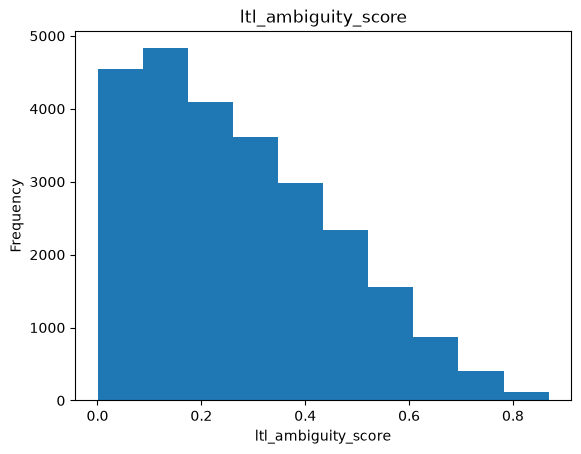

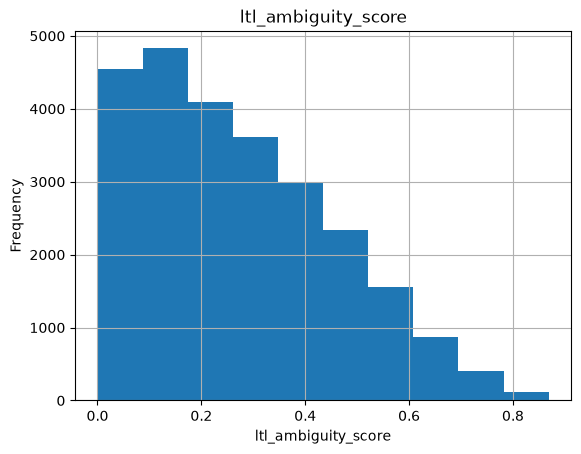

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

# Sample DataFrame

# Option A: Using .plot()
df_nonz["ltl_ambiguity_score"].plot(kind="hist", title="ltl_ambiguity_score")
plt.xlabel("ltl_ambiguity_score")
plt.show()

# Option B: Using .hist() directly
df_nonz["ltl_ambiguity_score"].hist()
plt.title("ltl_ambiguity_score")
plt.xlabel("ltl_ambiguity_score")
plt.ylabel("Frequency")
plt.show()

In [31]:

stats = df["ltl_ambiguity_score"].agg(["mean", "median"])
print(stats)



stats = df_nonz["ltl_ambiguity_score"].agg(["mean", "median"])
print(stats)

mean      0.173283
median    0.100888
Name: ltl_ambiguity_score, dtype: float64
mean      0.272753
median    0.244013
Name: ltl_ambiguity_score, dtype: float64
